<a href="https://colab.research.google.com/github/Gurekamjot003/Delta-Hedging-Adversarial-Stock-Path-Generation-Simulator/blob/main/HFT_CAMP_CODE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Uploading a CSV file to Google Colab

1.  **Click the 'Files' icon** on the left sidebar (it looks like a folder).
2.  **Click the 'Upload to session storage' icon** (it looks like a file with an arrow pointing up) and select your CSV file.
3.  Once uploaded, you can find the file in the `/content/` directory.

After you've uploaded the file (e.g., `your_file_05_feb.csv`), you can load it into a pandas DataFrame like this:

In [1]:
from google.colab import files

uploaded = files.upload()

# Get the name of the uploaded file
if uploaded:
    uploaded_file_name = list(uploaded.keys())[0]
    print(f"File '{uploaded_file_name}' uploaded successfully.")
else:
    print("No file was uploaded.")

Saving 20260204_option_minute_prices_non_expiry.csv to 20260204_option_minute_prices_non_expiry.csv
File '20260204_option_minute_prices_non_expiry.csv' uploaded successfully.


In [2]:
import pandas as pd

# Use the name of the uploaded file to load the DataFrame
file_name = uploaded_file_name
df_feb05 = pd.read_csv(file_name)

print(f"Successfully loaded '{file_name}' into a DataFrame.")

# Display the first 5 rows to verify
display(df_feb05.head())

Successfully loaded '20260204_option_minute_prices_non_expiry.csv' into a DataFrame.


,date,minute_end,symbol,last_trade_price
0,20260204,91600,NIFTY26FEBFUT,2575220.0
1,20260204,91600,NIFTY2621025550CE,26215.0
2,20260204,91600,NIFTY2621025600CE,23205.0
3,20260204,91600,NIFTY2621025650CE,20300.0
4,20260204,91600,NIFTY2621025700CE,17675.0


### Step 1: Filter Data and Extract Futures Price

First, we'll filter the DataFrame for options data at 11:00:00 (which corresponds to `minute_end = 110000`). We'll also extract the future price and parse the option symbols to get the strike prices and whether they are Call (CE) or Put (PE) options.

In [3]:
import numpy as np
import pandas as pd

# Filter for 11 AM (11:00:00)
# Ensure 'minute_end' is treated as an integer for filtering
filtered_df = df_feb05[df_feb05['minute_end'] == 110000].copy()

# Extract Future Price
futures_row = filtered_df[filtered_df['symbol'].str.contains('FUT')]
if not futures_row.empty:
    S_paisa = futures_row['last_trade_price'].iloc[0]
    S = S_paisa # Convert paisa to rupees
    print(f"Future Price (S) at 11 AM (in rupees): {S}")
else:
    S = None
    print("Future price not found at 11 AM. Cannot calculate Greeks or IV without S.")

# Filter out the futures row from the options data
options_df = filtered_df[~filtered_df['symbol'].str.contains('FUT')].copy()

# Parse option symbols to get Strike Price and Option Type (CE/PE)
def parse_symbol(symbol):
    option_type = None
    strike = None

    if 'CE' in symbol:
        option_type = 'call'
        strike_part = symbol.split('CE')[0]
        # Extract last 5 digits from the numeric part before 'CE'
        digits_only = ''.join(filter(str.isdigit, strike_part))
        if len(digits_only) >= 5:
            strike = float(digits_only[-5:])
    elif 'PE' in symbol:
        option_type = 'put'
        strike_part = symbol.split('PE')[0]
        # Extract last 5 digits from the numeric part before 'PE'
        digits_only = ''.join(filter(str.isdigit, strike_part))
        if len(digits_only) >= 5:
            strike = float(digits_only[-5:])

    return strike, option_type

options_df[['strike', 'option_type']] = options_df['symbol'].apply(lambda x: pd.Series(parse_symbol(x)))

# Convert strike and last_trade_price from paisa to rupees
options_df['strike'] = options_df['strike'] * 100.0
options_df['last_trade_price'] = options_df['last_trade_price']

# Drop rows where parsing failed or strike is None
options_df.dropna(subset=['strike', 'option_type'], inplace=True)

# Combine 'date' (e.g., 20260205) and 'minute_end' (e.g., 110000) into a single datetime object
options_df['observation_datetime_str'] = options_df['date'].astype(str) + options_df['minute_end'].astype(str).str.zfill(6)
options_df['observation_datetime'] = pd.to_datetime(options_df['observation_datetime_str'], format='%Y%m%d%H%M%S')

# User specified expiration date and time: 0502 (Feb 5th) at 3:30 PM (15:30)
expiration_date = pd.to_datetime('2026-02-05 15:30:00')

# Calculate Time to Expiration (T) in years
# dt.total_seconds() gives seconds, then convert to years
options_df['T'] = (expiration_date - options_df['observation_datetime']).dt.total_seconds() / (365.25 * 24 * 3600)

# Assume a risk-free rate (r)
r = 0.05 # 5%

print(f"Number of options at 11 AM: {len(options_df)}")
display(options_df.head())

Future Price (S) at 11 AM (in rupees): 2581990.0
Number of options at 11 AM: 22


,date,minute_end,symbol,last_trade_price,strike,option_type,observation_datetime_str,observation_datetime,T
2393,20260204,110000,NIFTY2621025550CE,29500.0,2555000.0,call,20260204110000,2026-02-04 11:00:00,0.003251
2394,20260204,110000,NIFTY2621025600CE,26100.0,2560000.0,call,20260204110000,2026-02-04 11:00:00,0.003251
2395,20260204,110000,NIFTY2621025650CE,22815.0,2565000.0,call,20260204110000,2026-02-04 11:00:00,0.003251
2396,20260204,110000,NIFTY2621025700CE,19800.0,2570000.0,call,20260204110000,2026-02-04 11:00:00,0.003251
2397,20260204,110000,NIFTY2621025750CE,17045.0,2575000.0,call,20260204110000,2026-02-04 11:00:00,0.003251


In [ ]:
filtered_df

### Step 2: Define Black-Scholes Model and Greeks Calculation

Next, we'll implement the Black-Scholes formula to calculate option prices and the associated Greeks (Delta, Gamma, Theta). We'll use `scipy.stats.norm` for the cumulative distribution function (CDF).

In [4]:
from scipy.stats import norm

def black_scholes(S, K, T, r, sigma, option_type):
    if T <= 0: # Handle zero or negative time to expiration
        if option_type == 'call':
            return max(0, S - K), 0, 0, 0
        else:
            return max(0, K - S), 0, 0, 0

    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if option_type == 'call':
        price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
        delta = norm.cdf(d1)
        gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))
        theta = -(S * norm.pdf(d1) * sigma) / (2 * np.sqrt(T)) - r * K * np.exp(-r * T) * norm.cdf(d2)
    elif option_type == 'put':
        price = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)
        delta = norm.cdf(d1) - 1
        gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))
        theta = -(S * norm.pdf(d1) * sigma) / (2 * np.sqrt(T)) + r * K * np.exp(-r * T) * norm.cdf(-d2)
    else:
        raise ValueError("option_type must be 'call' or 'put'")

    return price, delta, gamma, theta

print("Black-Scholes function defined.")

Black-Scholes function defined.


### Step 3: Define Implied Volatility (IV) Solver

Calculating Implied Volatility (IV) involves finding the volatility that, when plugged into the Black-Scholes formula, yields the observed market price of the option. This requires an iterative method, as there's no direct algebraic solution. We'll use a simple bisection method for this.

In [5]:
def implied_volatility(observed_price, S, K, T, r, option_type, tol=1e-5, max_iter=100, verbose=False):
    low_vol = 0.001
    high_vol = 5.0 # Max reasonable volatility

    for i in range(max_iter):
        mid_vol = (low_vol + high_vol) / 2

        if verbose:
            print(f"Iteration {i+1}: low_vol={low_vol:.4f}, high_vol={high_vol:.4f}, mid_vol={mid_vol:.4f}")

        if mid_vol < 1e-6: # Avoid division by zero or extremely small sigma
            mid_vol = 1e-6

        bs_price, _, _, _ = black_scholes(S, K, T, r, mid_vol, option_type)

        if verbose:
            print(f"  BS Price: {bs_price:.2f}, Observed Price: {observed_price:.2f}, Diff: {bs_price - observed_price:.2f}")

        # Handle cases where BS price is very close to observed price
        if abs(bs_price - observed_price) < tol:
            return mid_vol

        if bs_price < observed_price:
            low_vol = mid_vol
        else:
            high_vol = mid_vol

        if (high_vol - low_vol) < tol:
            if verbose:
                print(f"Converged within tolerance at iteration {i+1}.")
            return mid_vol # Converged within tolerance

    if verbose:
        print("Max iterations reached, returning best guess.")
    return mid_vol # Return the best guess if max_iter reached

print("Implied Volatility solver defined.")

Implied Volatility solver defined.


### Step 4: Calculate Implied Volatility for all options

Now, we'll apply the `implied_volatility` function to each option in our filtered DataFrame. We'll add a new column for the calculated IV. We will handle cases where the future price `S` might not be available or where IV calculation fails.

In [6]:
if S is not None:
    options_df['implied_volatility'] = options_df.apply(
        lambda row: implied_volatility(row['last_trade_price'], S, row['strike'], row['T'], r, row['option_type'], verbose=True)
        if row['T'] > 0 else 0, axis=1
    )
else:
    options_df['implied_volatility'] = np.nan
    print("Cannot calculate implied volatility as future price (S) is not available.")

display(options_df[['symbol', 'strike', 'option_type', 'last_trade_price', 'implied_volatility']].head())

Iteration 1: low_vol=0.0010, high_vol=5.0000, mid_vol=2.5005
  BS Price: 160070.77, Observed Price: 29500.00, Diff: 130570.77
Iteration 2: low_vol=0.0010, high_vol=2.5005, mid_vol=1.2508
  BS Price: 87574.20, Observed Price: 29500.00, Diff: 58074.20
Iteration 3: low_vol=0.0010, high_vol=1.2508, mid_vol=0.6259
  BS Price: 51887.72, Observed Price: 29500.00, Diff: 22387.72
Iteration 4: low_vol=0.0010, high_vol=0.6259, mid_vol=0.3134
  BS Price: 35184.17, Observed Price: 29500.00, Diff: 5684.17
Iteration 5: low_vol=0.0010, high_vol=0.3134, mid_vol=0.1572
  BS Price: 28722.76, Observed Price: 29500.00, Diff: -777.24
Iteration 6: low_vol=0.1572, high_vol=0.3134, mid_vol=0.2353
  BS Price: 31582.61, Observed Price: 29500.00, Diff: 2082.61
Iteration 7: low_vol=0.1572, high_vol=0.2353, mid_vol=0.1963
  BS Price: 30019.73, Observed Price: 29500.00, Diff: 519.73
Iteration 8: low_vol=0.1572, high_vol=0.1963, mid_vol=0.1767
  BS Price: 29330.79, Observed Price: 29500.00, Diff: -169.21
Iteration 9:

,symbol,strike,option_type,last_trade_price,implied_volatility
2393,NIFTY2621025550CE,2555000.0,call,29500.0,0.181733
2394,NIFTY2621025600CE,2560000.0,call,26100.0,0.198686
2395,NIFTY2621025650CE,2565000.0,call,22815.0,0.208163
2396,NIFTY2621025700CE,2570000.0,call,19800.0,0.215715
2397,NIFTY2621025750CE,2575000.0,call,17045.0,0.221760


### Plot: Implied Volatility

Let's visualize the calculated Implied Volatility against the strike price. This plot often reveals the 'volatility smile' or 'volatility skew,' indicating how market participants perceive future volatility across different strike prices.

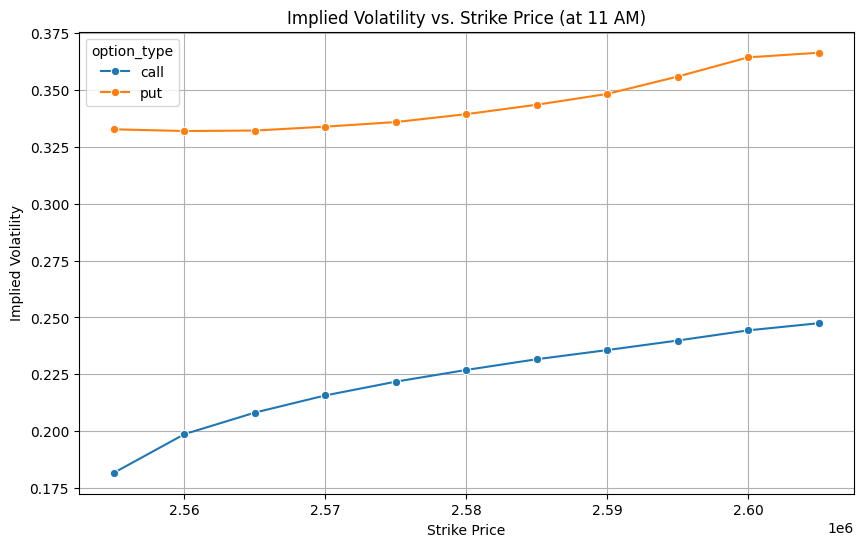

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.lineplot(data=options_df, x='strike', y='implied_volatility', hue='option_type', marker='o')
plt.title('Implied Volatility vs. Strike Price (at 11 AM)')
plt.xlabel('Strike Price')
plt.ylabel('Implied Volatility')
plt.grid(True)
plt.show()

### Step 5: Calculate Greeks for all options using Implied Volatility

With the implied volatility calculated, we can now use it in the Black-Scholes model to derive the Delta, Gamma, and Theta for each option.

In [8]:
if S is not None:
    options_df[['bs_price', 'delta', 'gamma', 'theta']] = options_df.apply(
        lambda row:
            pd.Series(black_scholes(
                S, row['strike'], row['T'], r, row['implied_volatility'], row['option_type']
            ))
        if row['T'] > 0 and not pd.isna(row['implied_volatility']) else pd.Series([np.nan, np.nan, np.nan, np.nan]), axis=1
    )
else:
    options_df[['bs_price', 'delta', 'gamma', 'theta']] = np.nan
    print("Cannot calculate Greeks as future price (S) is not available.")

display(options_df[['symbol', 'strike', 'option_type', 'last_trade_price', 'implied_volatility', 'delta', 'gamma', 'theta']].head())

,symbol,strike,option_type,last_trade_price,implied_volatility,delta,gamma,theta
2393,NIFTY2621025550CE,2555000.0,call,29500.0,0.181733,0.849654,0.000009,-1.069063e+06
2394,NIFTY2621025600CE,2560000.0,call,26100.0,0.198686,0.780830,0.000010,-1.428595e+06
2395,NIFTY2621025650CE,2565000.0,call,22815.0,0.208163,0.717641,0.000011,-1.684488e+06
2396,NIFTY2621025700CE,2570000.0,call,19800.0,0.215715,0.654606,0.000012,-1.883771e+06
2397,NIFTY2621025750CE,2575000.0,call,17045.0,0.221760,0.592340,0.000012,-2.024789e+06


In [9]:
S

np.float64(2581990.0)

### Step 6: Plot Delta

Let's visualize how Delta varies with the strike price for both Call and Put options. Delta measures the sensitivity of the option price to changes in the underlying asset's price.

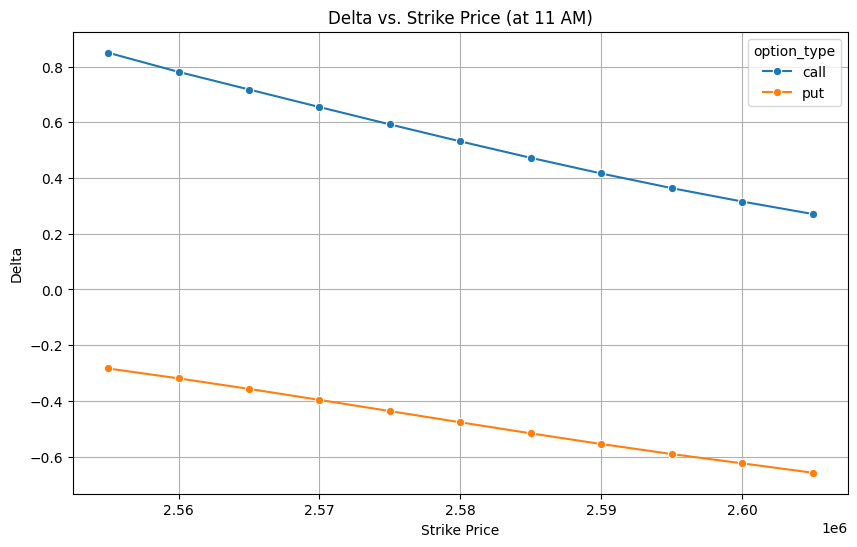

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.lineplot(data=options_df, x='strike', y='delta', hue='option_type', marker='o')
plt.title('Delta vs. Strike Price (at 11 AM)')
plt.xlabel('Strike Price')
plt.ylabel('Delta')
plt.grid(True)
plt.show()

### Step 7: Plot Gamma

Now, we'll plot Gamma against the strike price. Gamma measures the rate of change of Delta with respect to changes in the underlying asset's price, indicating how sensitive Delta is.

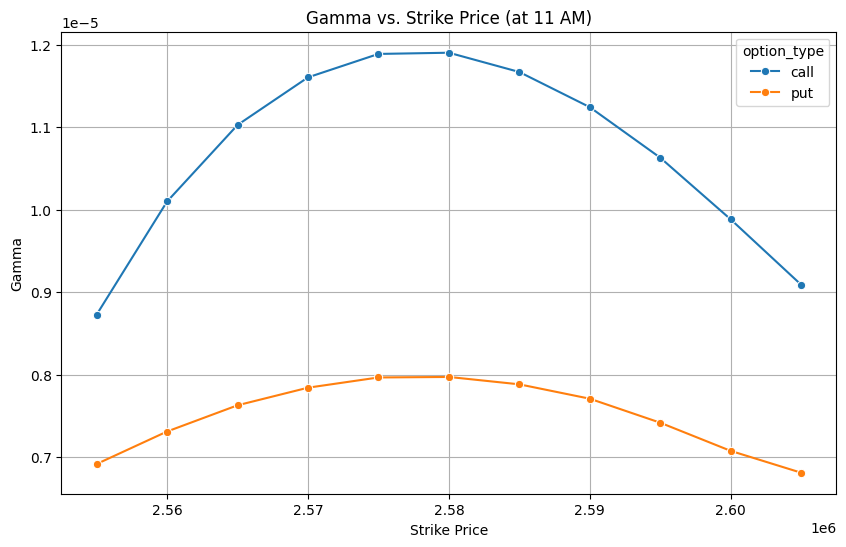

In [11]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=options_df, x='strike', y='gamma', hue='option_type', marker='o')
plt.title('Gamma vs. Strike Price (at 11 AM)')
plt.xlabel('Strike Price')
plt.ylabel('Gamma')
plt.grid(True)
plt.show()

### Step 8: Plot Theta

Next, we'll visualize Theta against the strike price. Theta, also known as 'time decay,' measures the rate at which an option's price erodes as time passes, all else being equal.

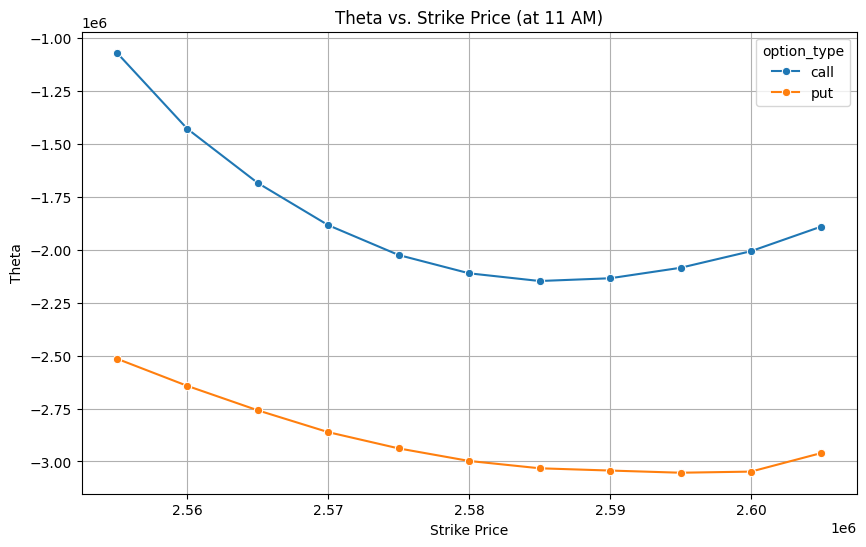

In [12]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=options_df, x='strike', y='theta', hue='option_type', marker='o')
plt.title('Theta vs. Strike Price (at 11 AM)')
plt.xlabel('Strike Price')
plt.ylabel('Theta')
plt.grid(True)
plt.show()

Starting Delta Hedging Simulation for Call option with Strike 2570000.0 using Implied Volatility
Risk-free rate (r) = 0.05
Dataset contains 375 price points from 2026-02-04 09:16:00 to 2026-02-04 15:30:00.

--- Delta Hedging Results (using Implied Volatility) ---
Final Underlying Price (S_T): 2583000.00
Option Payoff at Expiry (-Z_T, from hedger's perspective): -13000.00
Cumulative Trading P&L from Delta Hedging: 3358.08
Total P&L from Delta Hedging (PL_T): -9641.92


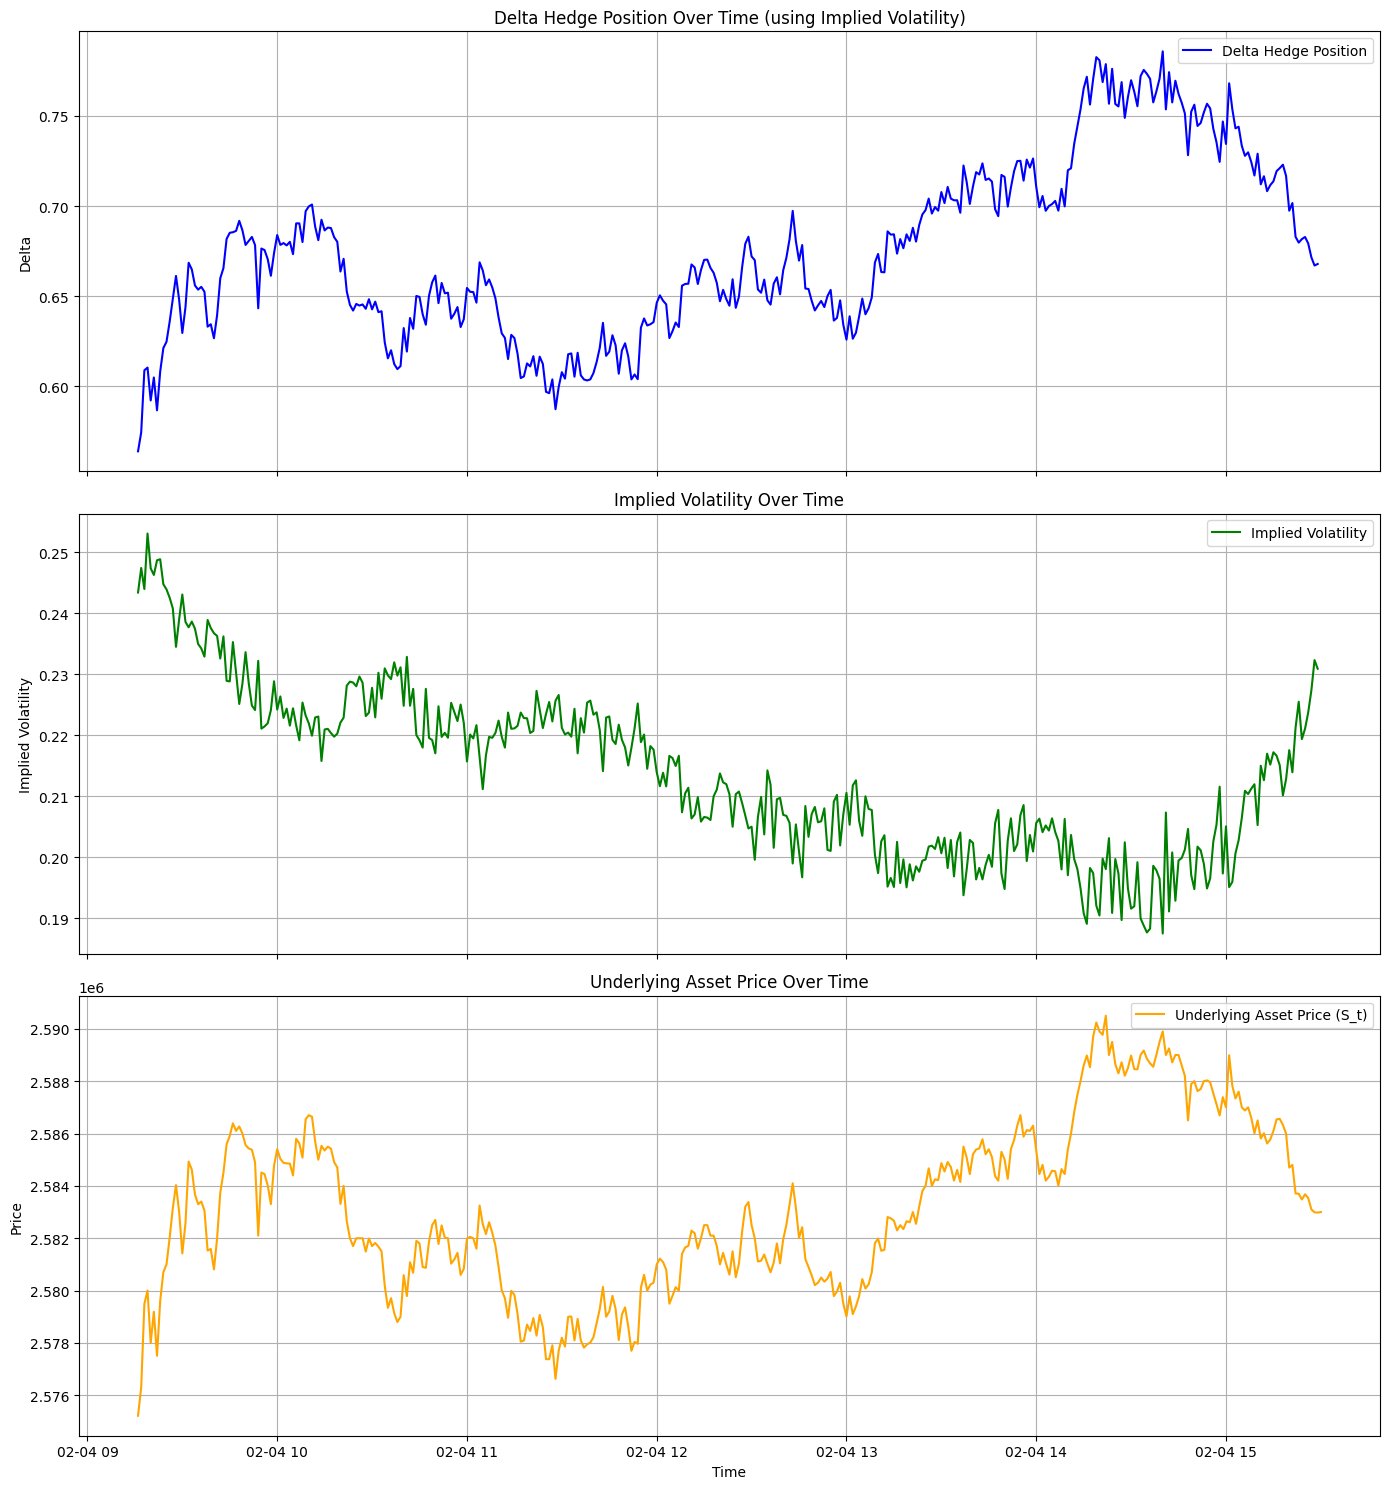

In [13]:
import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt
import seaborn as sns

# --- Black-Scholes function (assuming it's defined in a previous cell, included here for context) ---
def black_scholes(S, K, T, r, sigma, option_type):
    if T <= 0: # Handle zero or negative time to expiration
        if option_type == 'call':
            delta = 1.0 if S > K else 0.0
            return max(0, S - K), delta, 0, 0
        else:
            delta = -1.0 if S < K else 0.0
            return max(0, K - S), delta, 0, 0

    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if option_type == 'call':
        price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
        delta = norm.cdf(d1)
        gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))
        theta = -(S * norm.pdf(d1) * sigma) / (2 * np.sqrt(T)) - r * K * np.exp(-r * T) * norm.cdf(d2)
    elif option_type == 'put':
        price = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1) # Corrected put price formula
        delta = norm.cdf(d1) - 1
        gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))
        theta = -(S * norm.pdf(d1) * sigma) / (2 * np.sqrt(T)) + r * K * np.exp(-r * T) * norm.cdf(-d2)
    else:
        raise ValueError("option_type must be 'call' or 'put'")

    return price, delta, gamma, theta

# --- Implied Volatility solver (re-defined for clarity, assuming it's available from previous steps) ---
def implied_volatility(observed_price, S, K, T, r, option_type, tol=1e-5, max_iter=100):
    low_vol = 0.001
    high_vol = 5.0

    if T <= 0:
        return 0 # Or handle appropriately, e.g., NaN if IV is not applicable at expiry

    for i in range(max_iter):
        mid_vol = (low_vol + high_vol) / 2

        if mid_vol < 1e-6:
            mid_vol = 1e-6

        bs_price, _, _, _ = black_scholes(S, K, T, r, mid_vol, option_type)

        if abs(bs_price - observed_price) < tol:
            return mid_vol

        if bs_price < observed_price:
            low_vol = mid_vol
        else:
            high_vol = mid_vol

        if (high_vol - low_vol) < tol:
            return mid_vol

    return mid_vol # Return the best guess if max_iter reached

# --- Delta Hedging Implementation with Implied Volatility ---

# 1. Identify the target ATM option: NIFTY2621025700CE (Strike 2570000, Call)
target_strike = 2570000.0
target_option_type = 'call'
target_symbol_contains = 'NIFTY2621025700CE' # Specific symbol for the option

# Parameters for Black-Scholes and hedging
K = target_strike
r = 0.05 # Risk-free rate

# Prepare the full DataFrame for minute-by-minute simulation
df_iv_hedge = df_feb05.copy()

df_iv_hedge['observation_datetime_str'] = df_iv_hedge['date'].astype(str) + \
                                             df_iv_hedge['minute_end'].astype(str).str.zfill(6)
df_iv_hedge['observation_datetime'] = pd.to_datetime(df_iv_hedge['observation_datetime_str'], format='%Y%m%d%H%M%S')

# User specified expiration date and time: 0502 (Feb 5th) at 3:30 PM (15:30)
expiration_date = pd.to_datetime('2026-02-05 15:30:00')

# Get the time series data for future prices and the target option
future_prices_df = df_iv_hedge[df_iv_hedge['symbol'].str.contains('FUT')].copy()
option_prices_df = df_iv_hedge[df_iv_hedge['symbol'] == target_symbol_contains].copy()

# Merge them to ensure synchronized time steps
time_series_merged = pd.merge(future_prices_df, option_prices_df,
                              on='observation_datetime', suffixes=('_fut', '_opt'))
time_series_merged = time_series_merged.sort_values('observation_datetime').reset_index(drop=True)

# Calculate Time to Expiration (T) in years for each minute on the merged DataFrame
time_series_merged['T'] = (expiration_date - time_series_merged['observation_datetime']).dt.total_seconds() / (365.25 * 24 * 3600)

# Initialize hedging variables
cumulative_trading_pnl_iv_hedge = 0.0
delta_history_iv = []
iv_history = []
asset_price_history_iv = []

print(f"Starting Delta Hedging Simulation for {target_option_type.capitalize()} option with Strike {K} using Implied Volatility")
print(f"Risk-free rate (r) = {r}")

# Print information about the price points
num_price_points = len(time_series_merged)
first_timestamp = time_series_merged['observation_datetime'].min()
last_timestamp = time_series_merged['observation_datetime'].max()
print(f"Dataset contains {num_price_points} price points from {first_timestamp} to {last_timestamp}.")

# Loop through the time series data for delta hedging (up to the second to last minute)
for i in range(len(time_series_merged) - 1):
    S_ti = time_series_merged['last_trade_price_fut'].iloc[i]
    observed_option_price_ti = time_series_merged['last_trade_price_opt'].iloc[i]
    T_ti = time_series_merged['T'].iloc[i]

    # Calculate Implied Volatility at time t_i
    current_iv = implied_volatility(observed_option_price_ti, S_ti, K, T_ti, r, target_option_type)

    # If IV calculation fails or results in an invalid value, use a fallback (e.g., previous IV or a default)
    if pd.isna(current_iv) or current_iv <= 0:
        if iv_history: # Use previous IV if available
            current_iv = iv_history[-1]
        else: # Fallback to a default if no previous IV exists (e.g., initial fixed sigma)
            current_iv = 0.6 # This is similar to the fixed sigma in the previous step

    # Calculate delta at time t_i using Black-Scholes with the current implied volatility
    _, current_delta, _, _ = black_scholes(S_ti, K, T_ti, r, current_iv, target_option_type)

    delta_history_iv.append(current_delta)
    iv_history.append(current_iv)
    asset_price_history_iv.append(S_ti)

    # Get the price at the next minute (S_{ti+1})
    S_ti_plus_1 = time_series_merged['last_trade_price_fut'].iloc[i+1]

    # Contribution to P&L for this interval: delta_ti * (S_{ti+1} - S_ti)
    pnl_this_interval = current_delta * (S_ti_plus_1 - S_ti)
    cumulative_trading_pnl_iv_hedge += pnl_this_interval

# Final asset price at expiry (S_T is the last future price in the series)
S_T = time_series_merged['last_trade_price_fut'].iloc[-1]

# Calculate the option's payoff at expiry (Z_T) for the hedger (who sold the option)
if target_option_type == 'call':
    option_payoff_at_expiry = max(0, S_T - K)
elif target_option_type == 'put':
    option_payoff_at_expiry = max(0, K - S_T)
else:
    option_payoff_at_expiry = 0

# Calculate total PL_T using the provided formula (no transaction costs C_T(delta) = 0):
# PL_T = -Z_T + cumulative_trading_pnl - C_T(delta)
PL_T_iv_hedging = -option_payoff_at_expiry + cumulative_trading_pnl_iv_hedge

print(f"\n--- Delta Hedging Results (using Implied Volatility) ---")
print(f"Final Underlying Price (S_T): {S_T:.2f}")
print(f"Option Payoff at Expiry (-Z_T, from hedger's perspective): {-option_payoff_at_expiry:.2f}")
print(f"Cumulative Trading P&L from Delta Hedging: {cumulative_trading_pnl_iv_hedge:.2f}")
print(f"Total P&L from Delta Hedging (PL_T): {PL_T_iv_hedging:.2f}")

# --- Plotting the Delta, Implied Volatility, and Underlying Price ---
fig, axes = plt.subplots(3, 1, figsize=(14, 15), sharex=True)

# Plot 1: Delta Hedge Position
axes[0].plot(time_series_merged['observation_datetime'].iloc[:-1], delta_history_iv, label='Delta Hedge Position', color='blue')
axes[0].set_title('Delta Hedge Position Over Time (using Implied Volatility)')
axes[0].set_ylabel('Delta')
axes[0].grid(True)
axes[0].legend()

# Plot 2: Implied Volatility
axes[1].plot(time_series_merged['observation_datetime'].iloc[:-1], iv_history, label='Implied Volatility', color='green')
axes[1].set_title('Implied Volatility Over Time')
axes[1].set_ylabel('Implied Volatility')
axes[1].grid(True)
axes[1].legend()

# Plot 3: Underlying Asset Price
axes[2].plot(time_series_merged['observation_datetime'], time_series_merged['last_trade_price_fut'], label='Underlying Asset Price (S_t)', color='orange')
axes[2].set_title('Underlying Asset Price Over Time')
axes[2].set_xlabel('Time')
axes[2].set_ylabel('Price')
axes[2].grid(True)
axes[2].legend()

plt.tight_layout()
plt.show()

### Explanation of the Profit & Loss (PL) Equation for the Hedger

The Profit & Loss (PL) of the hedger (the option issuer) is formulated as follows:

**Equation (1): Total P&L**

`PL_T (Z, S, δ) := -Z(S) + (δ · S)_T - C_T(δ)`

Let's break down each component:

*   `PL_T`: This represents the total Profit & Loss at time `T` (expiry) for the hedger. A positive `PL_T` means the hedger made a profit, while a negative `PL_T` means a loss.

*   `-Z(S)`: This term represents the **loss from the option's payoff at expiry** from the hedger's perspective. The hedger is the seller of the option. If the option expires in-the-money, the hedger has to pay the option holder. This is a negative cash flow for the hedger.
    *   For a Call Option: `Z(S) = max(0, S_T - K)` (where `S_T` is the underlying price at expiry, `K` is the strike price). So, `-Z(S)` is `-max(0, S_T - K)`.
    *   For a Put Option: `Z(S) = max(0, K - S_T)`. So, `-Z(S)` is `-max(0, K - S_T)`.

*   `(δ · S)_T`: This term represents the **total return (or P&L) from dynamically trading the underlying asset** to hedge the option. This is the core of the delta hedging strategy.

*   `C_T(δ)`: This term represents the **total transaction costs** incurred from adjusting the hedge position `δ` over time. In our current simulation, we've assumed no transaction costs, so `C_T(δ)` is `0`.

**Equation (2): P&L from Trading the Underlying Asset**

`(δ · S)_T := Σ (from i=0 to n-1) [ δ_ti * (S_{ti+1} - S_ti) ]`

This is a sum over `n` time intervals (from `t_0` to `t_n-1`).

*   `δ_ti`: This is the delta hedge position held by the hedger during the time interval from `t_i` to `t_{i+1}`. It represents the number of units of the underlying asset bought or sold to maintain a delta-neutral position.
*   `(S_{ti+1} - S_ti)`: This is the change in the underlying asset's price during that specific time interval.

So, `δ_ti * (S_{ti+1} - S_ti)` represents the profit or loss generated by holding `δ_ti` units of the underlying asset as its price changes from `S_ti` to `S_{ti+1}`. Summing these up gives the total P&L from the hedging trades.

**Equation (3): Total Transaction Costs (Assumed 0 in our case)**

`C_T(δ) := Σ (from i=0 to n) [ c * S_ti * |δ_ti - δ_{ti-1}| ]`

This equation details how transaction costs are calculated if they were included:

*   `c`: This is the transaction cost rate (e.g., a percentage of the trade value).
*   `S_ti`: The price of the underlying asset at the time of adjustment.
*   `|δ_ti - δ_{ti-1}|`: The absolute change in the delta position. This represents the amount of the underlying asset that was bought or sold at time `t_i` to rebalance the hedge. Transaction costs are proportional to the size of these rebalancing trades.
*   The condition `δ_-1 = δ_tn = 0` means that at the beginning (before any hedging) and at the end (after expiry), there is no hedge position.

**In summary, the total P&L for the hedger is the sum of:**
1.  The payment made (or received) for the option at expiry (`-Z(S)`).
2.  The cumulative profit or loss from continually adjusting the hedge position in the underlying asset (`(δ · S)_T`).
3.  Minus any transaction costs (`-C_T(δ)`). Since we are currently assuming no transaction costs, the `C_T(δ)` term is 0, simplifying the equation to `PL_T = -Z(S) + (δ · S)_T`.

### Step 1: Generate Synthetic Price Paths using Geometric Brownian Motion (GBM)

To train our deep hedger, we need a large dataset of underlying asset price paths. We'll use Geometric Brownian Motion (GBM) to simulate these paths. GBM is a standard model for asset prices, assuming that prices follow a random walk with a constant drift and volatility.

Each simulated path will:
*   Start at the initial future price observed in our real market data.
*   Have the same number of discrete time steps (e.g., minutes) as our real data.
*   Use a specified constant volatility (0.6 as per your request).
*   Use the risk-free rate (r=0.05) as the drift for consistency with option pricing models.

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Parameters from our real market data
S0 = time_series_merged['last_trade_price_fut'].iloc[0] # Initial future price
num_steps = len(time_series_merged) - 1 # Number of minute intervals

# Calculate the total time in years (from start to end of the real data)
time_diff = (time_series_merged['observation_datetime'].iloc[-1] - time_series_merged['observation_datetime'].iloc[0]).total_seconds()
T_total_years = time_diff / (365.25 * 24 * 3600)
dt = T_total_years / num_steps # Time increment for each step

# GBM Parameters
mu = r # Drift (risk-free rate) for risk-neutral measure
sigma = 0.6 # Volatility as specified by the user
num_paths = 1000 # Number of price paths to generate (reverted to 1,000 as per user request)

def generate_gbm_path(S0, mu, sigma, dt, num_steps):
    '''Generates a single price path using Geometric Brownian Motion.'''
    prices = np.zeros(num_steps + 1)
    prices[0] = S0
    for i in range(1, num_steps + 1):
        # Z is a standard normal random variable
        Z = np.random.normal(0, 1)
        prices[i] = prices[i-1] * np.exp((mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z)
    return prices

# Generate multiple price paths
np.random.seed(42) # for reproducibility
synthetic_price_paths = []
for _ in range(num_paths):
    path = generate_gbm_path(S0, mu, sigma, dt, num_steps)
    synthetic_price_paths.append(path)

print(f"Generated {num_paths} synthetic price paths, each with {num_steps + 1} points.")
print(f"Initial price (S0): {S0:.2f}")
print(f"Drift (mu): {mu}")
print(f"Volatility (sigma): {sigma}")
print(f"Time step (dt) in years: {dt:.6f}")

Generated 1000 synthetic price paths, each with 375 points.
Initial price (S0): 2575220.00
Drift (mu): 0.05
Volatility (sigma): 0.6
Time step (dt) in years: 0.000002


### Visualization of Synthetic Price Paths

Let's plot the first few generated paths to get a sense of their behavior.

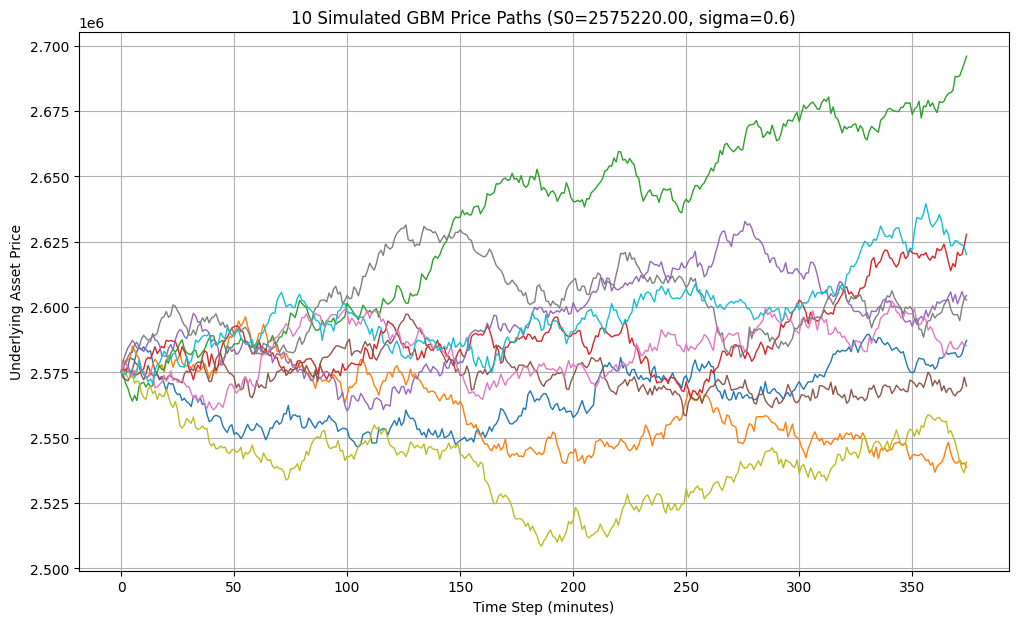

In [15]:
plt.figure(figsize=(12, 7))
for i in range(min(10, num_paths)): # Plot first 10 paths for clarity
    plt.plot(synthetic_price_paths[i], lw=1)
plt.title(f'{min(10, num_paths)} Simulated GBM Price Paths (S0={S0:.2f}, sigma={sigma})')
plt.xlabel('Time Step (minutes)')
plt.ylabel('Underlying Asset Price')
plt.grid(True)
plt.show()

### Next Steps for Training Data

Now that we have generated the underlying price paths, the next logical step is to:

1.  **Calculate Option Prices for each Path:** For each point in each simulated price path, we need to calculate the theoretical option price (and potentially its delta) using the Black-Scholes model. This will serve as the target for our deep hedging model or as input features.
2.  **Split into Training and Test Sets:** Divide these simulated paths into a training set for the RNN and a separate test set to evaluate its performance against delta hedging.
3.  **Implement the RNN Hedger:** Construct a simple RNN cell that takes inputs like `S_ti`, `I_ti` (e.g., Black-Scholes delta, volatility), and `δ_{ti-1}` to output the new hedge position `δ_ti`.

### Step 2: Calculate Black-Scholes Option Prices and Deltas for Synthetic Paths

For each generated GBM path, we need to calculate the theoretical Black-Scholes option price and its corresponding Delta at each time step. These will serve as target values and input features for our deep hedging model.

In [16]:
# Option parameters for Black-Scholes calculation (same as the real data option)
option_K = target_strike # Strike price (from previous real data analysis)
option_r = r             # Risk-free rate (from previous real data analysis)
option_type = 'call'     # Target option type

# We will use a constant volatility for these theoretical calculations,
# as the GBM paths were generated with a constant sigma (0.6). We'll use this.
theoretical_sigma = sigma # Use the same sigma as GBM generation (0.6)

# Prepare lists to store calculated Black-Scholes prices and deltas for all paths
all_bs_prices = []
all_bs_deltas = []

print(f"Calculating Black-Scholes prices and deltas for {num_paths} paths...")

# Iterate through each synthetic price path
for path_idx, s_path in enumerate(synthetic_price_paths):
    bs_prices_for_path = []
    bs_deltas_for_path = []

    # Iterate through each time step in the path
    for t_step in range(num_steps + 1):
        S_t = s_path[t_step]

        # Calculate time to expiration for this step
        # T decreases over time. T_total_years is the initial total time.
        # The remaining time is T_total_years - (t_step * dt)
        T_remaining = T_total_years - (t_step * dt)

        # Ensure T_remaining is not negative due to floating point precision at expiry
        if T_remaining < 0: T_remaining = 0

        # Calculate Black-Scholes price and delta
        price, delta, _, _ = black_scholes(S_t, option_K, T_remaining, option_r, theoretical_sigma, option_type)

        bs_prices_for_path.append(price)
        bs_deltas_for_path.append(delta)

    all_bs_prices.append(np.array(bs_prices_for_path))
    all_bs_deltas.append(np.array(bs_deltas_for_path))

# Convert to numpy arrays for easier manipulation
all_bs_prices = np.array(all_bs_prices)
all_bs_deltas = np.array(all_bs_deltas)

print(f"Finished calculating BS prices and deltas. Shape: {all_bs_prices.shape}")

# Display a sample (e.g., first path's prices and deltas)
print("\nSample Black-Scholes Prices for the first path (first 5 and last 5):")
print(all_bs_prices[0, :5])
print(all_bs_prices[0, -5:])

print("\nSample Black-Scholes Deltas for the first path (first 5 and last 5):")
print(all_bs_deltas[0, :5])
print(all_bs_deltas[0, -5:])

Calculating Black-Scholes prices and deltas for 1000 paths...
Finished calculating BS prices and deltas. Shape: (1000, 375)

Sample Black-Scholes Prices for the first path (first 5 and last 5):
[19212.55593579 19782.64806755 19594.40263954 20357.22642076
 22254.70235939]
[10944.14941973 10990.19373823 12051.40578193 15152.27952038
 17203.85507814]

Sample Black-Scholes Deltas for the first path (first 5 and last 5):
[0.554501   0.56470186 0.56194737 0.57522856 0.6060711 ]
[0.99487615 0.99855028 0.99996821 1.         1.        ]


### Step 3: Split Data into Training and Test Sets

We will now split the generated synthetic price paths, their corresponding Black-Scholes prices, and deltas into training and testing datasets. This is crucial for evaluating the performance of our Deep Hedger on unseen data.

In [17]:
from sklearn.model_selection import train_test_split

# Convert lists of arrays to a single numpy array if not already
synthetic_price_paths_array = np.array(synthetic_price_paths)

# Define the split ratio (e.g., 80% for training, 20% for testing)
test_size_ratio = 0.2

# Split the synthetic price paths
S_train, S_test = train_test_split(synthetic_price_paths_array, test_size=test_size_ratio, random_state=42)

# Split the corresponding Black-Scholes prices
BS_prices_train, BS_prices_test = train_test_split(all_bs_prices, test_size=test_size_ratio, random_state=42)

# Split the corresponding Black-Scholes deltas
BS_deltas_train, BS_deltas_test = train_test_split(all_bs_deltas, test_size=test_size_ratio, random_state=42)

print(f"Training set size: {len(S_train)} paths")
print(f"Test set size: {len(S_test)} paths")

print(f"Shape of S_train: {S_train.shape}")
print(f"Shape of BS_deltas_train: {BS_deltas_train.shape}")

Training set size: 800 paths
Test set size: 200 paths
Shape of S_train: (800, 375)
Shape of BS_deltas_train: (800, 375)


### Step 4: Implement the Deep Hedging RNN Model

We will now construct a simple Recurrent Neural Network (RNN) using TensorFlow/Keras to serve as our deep hedger. The goal of this RNN is to learn an optimal hedging strategy by outputting the next delta position based on current market information.

Our RNN will take the following inputs at each time step `t`:
1.  **`S_t`**: The current underlying asset price.
2.  **`BS_delta_t`**: The Black-Scholes delta at time `t` (using the theoretical sigma). This provides the model with relevant information about the option's sensitivity.
3.  **`delta_{t-1}`**: The delta position held from the previous time step `t-1`. This allows the RNN to learn a dynamic hedging strategy, considering its past actions.

The RNN will output **`delta_t`**, the new delta position to be held for the next interval.

In [18]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Concatenate

# --- Model Parameters ---
num_dense_units = 32 # Number of units in the single Dense layer

# --- Input Layers for a single time step ---
# Input for current asset price (S_t) - single value per time step
s_input_t = Input(shape=(1,), name='S_t_input')

# Input for Black-Scholes delta (BS_delta_t) - single value per time step
bs_delta_input_t = Input(shape=(1,), name='BS_delta_t_input')

# Input for previous delta position (delta_{t-1}) - single value per time step
prev_delta_input_t = Input(shape=(1,), name='prev_delta_input')

# --- Feature Concatenation ---
# Concatenate S_t, BS_delta_t, and prev_delta_t as features for the Dense layer
combined_features_t = Concatenate(axis=-1)([s_input_t, bs_delta_input_t, prev_delta_input_t])

# --- Single Dense Layer ---
# The Dense layer will process the combined features
dense_output = Dense(num_dense_units, activation='tanh')(combined_features_t)
output_delta_t = Dense(1, activation='tanh', name='delta_t_output')(dense_output) # Final output layer

# --- Create the Model for a single time step ---
# Renaming to `deep_hedger_model` to distinguish from a full sequence model
deep_hedger_model = Model(inputs=[s_input_t, bs_delta_input_t, prev_delta_input_t], outputs=output_delta_t)

deep_hedger_model.summary()

print("Deep Hedging model implemented as a single-step predictor, incorporating previous delta.")

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ S_t_input           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ BS_delta_t_input    │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ prev_delta_input    │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 3)         │          0 │ S_t_input[0][0],  │
│ (Concatenate)       │                   │            │ BS_delta_t_input… │
│                     │                   │            │ prev_delta_input… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │        128 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ delta_t_output      │ (None, 1)         │         33 │ dense[0][0]       │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 161 (644.00 B)

 Trainable params: 161 (644.00 B)

 Non-trainable params: 0 (0.00 B)

Deep Hedging model implemented as a single-step predictor, incorporating previous delta.


### Step 5: Define P&L Calculation and CVaR Loss Function (TensorFlow-compatible)

To train our deep hedger using CVaR as a loss function, we first need a TensorFlow-compatible way to calculate the P&L for a given hedging strategy (sequence of deltas) and a price path. Then, we'll define the CVaR loss itself.

#### P&L Calculation Function
This function will simulate the hedging process for a given path and sequence of deltas generated by the model. It will calculate the total P&L at expiry based on the formula: `PL_T = -Z(S) + (δ · S)_T` (assuming no transaction costs).

#### CVaR Loss Function
CVaR (Conditional Value at Risk), also known as Expected Shortfall, measures the expected loss beyond a certain percentile (VaR). For a hedging problem, we want to minimize the expected losses in the worst-case scenarios. If `P` is the distribution of P&L values, and `alpha` is the confidence level (e.g., 0.05 for 5%), then CVaR($\alpha$) is the expected P&L conditional on the P&L being below the $\alpha$-percentile (the VaR).

$$ \text{CVaR}_\alpha = E[\text{PL} | \text{PL} \le \text{VaR}_\alpha] $$

In [19]:
import tensorflow as tf

# Assuming option_K, r, option_type, dt are already defined globally or passed
# target_strike, r, option_type, dt

@tf.function
def calculate_pnl(S_path_batch, deltas_batch, K, r_tf, option_type_str):
    """
    Calculates the P&L for a batch of price paths and corresponding delta hedges.

    Args:
        S_path_batch (tf.Tensor): Batch of underlying price paths (batch_size, num_steps + 1).
        deltas_batch (tf.Tensor): Batch of delta hedges (batch_size, num_steps + 1).
                                 deltas_batch[..., t] is the delta held from t to t+1.
        K (tf.Tensor): Strike price.
        r_tf (tf.Tensor): Risk-free rate.
        option_type_str (tf.Tensor): String tensor indicating 'call' or 'put'.

    Returns:
        tf.Tensor: A tensor of P&L values for each path in the batch (batch_size,).
    """
    # Ensure tensors are float32 for consistency
    S_path_batch = tf.cast(S_path_batch, tf.float32)
    deltas_batch = tf.cast(deltas_batch, tf.float32)
    K = tf.cast(K, tf.float32)
    r_tf = tf.cast(r_tf, tf.float32)

    # Reshape deltas_batch to (batch_size, num_steps + 1) if it's (batch_size, num_steps + 1, 1)
    if len(deltas_batch.shape) == 3: # Handle case where delta_output is (batch_size, timesteps, 1)
        deltas_batch = tf.squeeze(deltas_batch, axis=-1)

    # S_t is S_path_batch[:, :-1]
    # S_{t+1} is S_path_batch[:, 1:]
    price_changes = S_path_batch[:, 1:] - S_path_batch[:, :-1]

    # Delta position at time t is held from t to t+1. So we use deltas_batch[:, :-1] (or just deltas_batch) for trading P&L
    # The last delta in deltas_batch is the delta at expiry, which contributes to the final option value, not trading PnL
    # This matches the (delta . S)_T definition in the paper where delta_ti is for (S_{ti+1} - S_ti)
    trading_pnl_per_interval = deltas_batch[:, :-1] * price_changes
    cumulative_trading_pnl = tf.reduce_sum(trading_pnl_per_interval, axis=1)

    # Option payoff at expiry (Z_T)
    S_T = S_path_batch[:, -1] # Final underlying price

    # Check option type using tf.strings.equal
    is_call = tf.cast(tf.strings.bytes_split(option_type_str)[0] == tf.constant(b'c'), tf.float32)

    option_payoff_at_expiry_call = tf.maximum(0.0, S_T - K)
    option_payoff_at_expiry_put = tf.maximum(0.0, K - S_T)

    # Use tf.where to select based on option type
    option_payoff_at_expiry = tf.where(
        tf.cast(is_call, tf.bool),
        option_payoff_at_expiry_call,
        option_payoff_at_expiry_put
    )

    # Total P&L: -Z_T + cumulative_trading_pnl (no transaction costs)
    total_pnl = -option_payoff_at_expiry + cumulative_trading_pnl

    return total_pnl

@tf.function
def cvar_loss(pnl_values, alpha=0.05):
    """
    Calculates the CVaR (Conditional Value at Risk) loss for a batch of P&L values.
    CVaR is the expected loss in the worst 'alpha' percentile.

    Args:
        pnl_values (tf.Tensor): A batch of P&L values (batch_size,).
        alpha (float): The significance level for CVaR (e.g., 0.05 for 5%).

    Returns:
        tf.Tensor: The CVaR loss (scalar).
    """
    # Sort P&L values in ascending order (from worst loss to best profit)
    sorted_pnl = tf.sort(pnl_values)

    # Calculate the index for VaR_alpha (worst 'alpha' percentage)
    num_samples = tf.cast(tf.shape(sorted_pnl)[0], tf.float32)
    cvar_index = tf.cast(tf.floor(num_samples * alpha), tf.int32)

    # Select the worst 'alpha' percentile of P&L values
    # Note: tf.slice is exclusive of the end index, so we need to go up to cvar_index
    worst_pnl_values = sorted_pnl[:cvar_index + 1] # Include up to the alpha-th percentile

    # CVaR is the negative of the average of these worst P&L values
    # We want to minimize the loss, so we minimize -CVaR or maximize CVaR.
    # Conventionally, CVaR is expressed as a positive loss, so we take the negative mean of P&L
    # PNL is profit, so minimizing average PNL means making profits smaller.
    # If PNL is negative (a loss), then -PNL is positive, and minimizing it means minimizing the loss.
    # So, CVaR loss will be -mean(worst_pnl_values)
    cvar_value = -tf.reduce_mean(worst_pnl_values)

    return cvar_value

print("TensorFlow-compatible P&L calculation and CVaR loss functions defined.")

TensorFlow-compatible P&L calculation and CVaR loss functions defined.


### Step 6: Implement Custom Training Loop for Deep Hedger

Now we will implement the custom training loop to train our `deep_hedger_model`. This loop will iterate through the synthetic training data, calculate the P&L for each generated path using the model's predicted deltas, compute the CVaR loss, and update the model's weights using an optimizer.

**Training Process:**
1.  **Initialize Optimizer:** We'll use the Adam optimizer.
2.  **Epochs and Batches:** The training will run for a specified number of epochs, and data will be processed in batches.
3.  **Dynamic Delta Prediction:** For each path in a batch, the model will predict the delta at each time step. Importantly, the `delta_prev` (the previous delta) will be fed back into the model as an input at each step, enabling the model to learn a sequential hedging strategy.
4.  **P&L Calculation:** After predicting all deltas for a path, the `calculate_pnl` function will be used to determine the P&L for that path.
5.  **CVaR Loss:** The `cvar_loss` function will then compute the Conditional Value at Risk based on the batch's P&L values.
6.  **Gradient Descent:** TensorFlow's `GradientTape` will automatically compute the gradients of the CVaR loss with respect to the model's trainable weights, and the optimizer will apply these gradients to update the weights.

In [20]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
epochs = 100
batch_size = 32 # Can be adjusted

num_train_paths = S_train.shape[0]
num_time_steps = S_train.shape[1] # This includes S_0 to S_T

# Convert numpy arrays to TensorFlow datasets
train_dataset = tf.data.Dataset.from_tensor_slices(
    (S_train, BS_deltas_train)
).shuffle(num_train_paths).batch(batch_size)

print(f"Starting Deep Hedging Model Training for {epochs} epochs...")

for epoch in range(epochs):
    epoch_loss_avg = tf.keras.metrics.Mean()
    for step, (batch_S_paths, batch_BS_deltas) in enumerate(train_dataset):
        with tf.GradientTape() as tape:
            # Initialize an empty TensorArray to store predicted deltas for this batch
            # The size is num_time_steps because we predict delta_0 to delta_{T}
            batch_predicted_deltas_ta = tf.TensorArray(tf.float32, size=num_time_steps, dynamic_size=False, clear_after_read=False)

            # Initial delta_prev for each path in the batch (start with 0 hedge)
            delta_prev = tf.zeros((batch_S_paths.shape[0], 1), dtype=tf.float32)

            # Iterate through time steps to get predicted deltas for each path in the batch
            for t in tf.range(num_time_steps):
                # Prepare inputs for the deep_hedger_model for the current time step `t`
                S_t_batch = tf.expand_dims(batch_S_paths[:, t], axis=-1)         # (batch_size, 1)
                BS_delta_t_batch = tf.expand_dims(batch_BS_deltas[:, t], axis=-1) # (batch_size, 1)

                # Get the predicted delta for the current time step from the model
                predicted_delta_t = deep_hedger_model([S_t_batch, BS_delta_t_batch, delta_prev])

                # Store the predicted delta
                batch_predicted_deltas_ta = batch_predicted_deltas_ta.write(t, predicted_delta_t)

                # Update delta_prev for the next time step
                delta_prev = predicted_delta_t

            # Stack the predicted deltas from the TensorArray. Resulting shape: (num_time_steps, batch_size, 1)
            # Transpose to get (batch_size, num_time_steps, 1), then squeeze to (batch_size, num_time_steps)
            final_predicted_deltas_seq = tf.transpose(batch_predicted_deltas_ta.stack(), perm=[1, 0, 2])
            final_predicted_deltas_squeezed = tf.squeeze(final_predicted_deltas_seq, axis=-1) # (batch_size, num_time_steps)

            # Calculate P&L for the entire batch of paths using the predicted deltas
            pnl_values = calculate_pnl(
                batch_S_paths,
                final_predicted_deltas_squeezed,
                tf.constant(option_K, dtype=tf.float32),
                tf.constant(option_r, dtype=tf.float32),
                tf.constant(option_type, dtype=tf.string)
            )

            # Calculate the CVaR loss from the P&L values
            loss = cvar_loss(pnl_values, alpha=0.05)

        # Compute and apply gradients
        gradients = tape.gradient(loss, deep_hedger_model.trainable_variables)
        optimizer.apply_gradients(zip(gradients, deep_hedger_model.trainable_variables))

        epoch_loss_avg.update_state(loss)

    print(f"Epoch {epoch+1}/{epochs}, CVaR Loss: {epoch_loss_avg.result():.4f}")

print("\nDeep Hedging Model Training Complete.")

Starting Deep Hedging Model Training for 100 epochs...
Epoch 1/100, CVaR Loss: 155501.9062
Epoch 2/100, CVaR Loss: 125498.6719
Epoch 3/100, CVaR Loss: 54749.1719
Epoch 4/100, CVaR Loss: 48096.3438
Epoch 5/100, CVaR Loss: 48881.1797
Epoch 6/100, CVaR Loss: 48093.7344
Epoch 7/100, CVaR Loss: 48676.4648
Epoch 8/100, CVaR Loss: 47811.0898
Epoch 9/100, CVaR Loss: 48319.1758
Epoch 10/100, CVaR Loss: 48822.0742
Epoch 11/100, CVaR Loss: 47357.5117


KeyboardInterrupt: 

### Step 7: Evaluate Model Performance

Now that the deep hedging model is trained, we need to evaluate its performance against the traditional Black-Scholes delta hedging strategy on both the synthetic training and test datasets. This will involve:

1.  **Calculating P&L** for the Deep Hedger and Black-Scholes Delta Hedger for each path in the train and test sets.
2.  **Plotting P&L distributions** (histograms) to visually compare the hedging effectiveness.
3.  **Quantifying risk** by calculating Value at Risk (VaR) and Conditional Value at Risk (CVaR) for each scenario.

In [21]:
# Helper function to predict deltas for a given set of paths
@tf.function
def predict_deltas_for_paths(model, S_paths, BS_deltas_input, num_time_steps):
    all_predicted_deltas = tf.TensorArray(tf.float32, size=S_paths.shape[0], dynamic_size=False, clear_after_read=False)

    for i in tf.range(S_paths.shape[0]): # Iterate over each path in the batch
        s_path = S_paths[i]
        bs_deltas_path = BS_deltas_input[i]

        path_predicted_deltas_ta = tf.TensorArray(tf.float32, size=num_time_steps, dynamic_size=False, clear_after_read=False)
        delta_prev = tf.zeros((1, 1), dtype=tf.float32) # Initial delta for a single path

        for t in tf.range(num_time_steps):
            S_t = tf.expand_dims(s_path[t], axis=0) # (1, 1)
            BS_delta_t = tf.expand_dims(bs_deltas_path[t], axis=0) # (1, 1)

            predicted_delta_t = model([S_t, BS_delta_t, delta_prev])
            path_predicted_deltas_ta = path_predicted_deltas_ta.write(t, predicted_delta_t)
            delta_prev = predicted_delta_t

        final_path_predicted_deltas = tf.squeeze(path_predicted_deltas_ta.stack(), axis=-1) # (num_time_steps,)
        all_predicted_deltas = all_predicted_deltas.write(i, final_path_predicted_deltas)

    return all_predicted_deltas.stack()

print("Calculating P&L for Deep Hedger on Train Set...")
# Deep Hedger P&L on Train Set
dh_predicted_deltas_train = predict_deltas_for_paths(
    deep_hedger_model, S_train, BS_deltas_train, num_time_steps
)
dh_pnl_train = calculate_pnl(
    S_train,
    dh_predicted_deltas_train,
    tf.constant(option_K, dtype=tf.float32),
    tf.constant(option_r, dtype=tf.float32),
    tf.constant(option_type, dtype=tf.string)
).numpy() # Convert to numpy for analysis

print("Calculating P&L for Deep Hedger on Test Set...")
# Deep Hedger P&L on Test Set
dh_predicted_deltas_test = predict_deltas_for_paths(
    deep_hedger_model, S_test, BS_deltas_test, num_time_steps
)
dh_pnl_test = calculate_pnl(
    S_test,
    dh_predicted_deltas_test,
    tf.constant(option_K, dtype=tf.float32),
    tf.constant(option_r, dtype=tf.float32),
    tf.constant(option_type, dtype=tf.string)
).numpy() # Convert to numpy for analysis

print("Deep Hedger P&L calculated for train and test sets.")

Calculating P&L for Deep Hedger on Train Set...
Calculating P&L for Deep Hedger on Test Set...
Deep Hedger P&L calculated for train and test sets.


In [22]:
print("Calculating P&L for Black-Scholes Delta Hedging on Train Set...")

# Black-Scholes Delta Hedging P&L on Train Set
bs_pnl_train = []
for path_idx in range(S_train.shape[0]):
    s_path = S_train[path_idx]
    # Use the pre-calculated Black-Scholes deltas directly
    bs_deltas_for_path_tf = tf.constant(BS_deltas_train[path_idx], dtype=tf.float32)

    pnl = calculate_pnl(
        tf.expand_dims(tf.constant(s_path, dtype=tf.float32), axis=0),
        tf.expand_dims(bs_deltas_for_path_tf, axis=0),
        tf.constant(option_K, dtype=tf.float32),
        tf.constant(option_r, dtype=tf.float32),
        tf.constant(option_type, dtype=tf.string)
    ).numpy()[0]
    bs_pnl_train.append(pnl)
bs_pnl_train = np.array(bs_pnl_train)

print("Calculating P&L for Black-Scholes Delta Hedging on Test Set...")

# Black-Scholes Delta Hedging P&L on Test Set
bs_pnl_test = []
for path_idx in range(S_test.shape[0]):
    s_path = S_test[path_idx]
    # Use the pre-calculated Black-Scholes deltas directly
    bs_deltas_for_path_tf = tf.constant(BS_deltas_test[path_idx], dtype=tf.float32)

    pnl = calculate_pnl(
        tf.expand_dims(tf.constant(s_path, dtype=tf.float32), axis=0),
        tf.expand_dims(bs_deltas_for_path_tf, axis=0),
        tf.constant(option_K, dtype=tf.float32),
        tf.constant(option_r, dtype=tf.float32),
        tf.constant(option_type, dtype=tf.string)
    ).numpy()[0]
    bs_pnl_test.append(pnl)
bs_pnl_test = np.array(bs_pnl_test)

print("Black-Scholes Delta Hedging P&L calculated for train and test sets.")

Calculating P&L for Black-Scholes Delta Hedging on Train Set...
Calculating P&L for Black-Scholes Delta Hedging on Test Set...
Black-Scholes Delta Hedging P&L calculated for train and test sets.


In [23]:
def calculate_var(pnl_values, alpha=0.05):
    """
    Calculates Value at Risk (VaR) for a given set of P&L values.
    """
    pnl_values_sorted = np.sort(pnl_values)
    index = int(np.floor(len(pnl_values_sorted) * alpha))
    return pnl_values_sorted[index]

# Convert the tf.function cvar_loss to a numpy-compatible function for reporting
def calculate_cvar_numpy(pnl_values, alpha=0.05):
    return cvar_loss(tf.constant(pnl_values, dtype=tf.float32), alpha=alpha).numpy()

print("VaR and NumPy-compatible CVaR calculation functions defined.")

VaR and NumPy-compatible CVaR calculation functions defined.


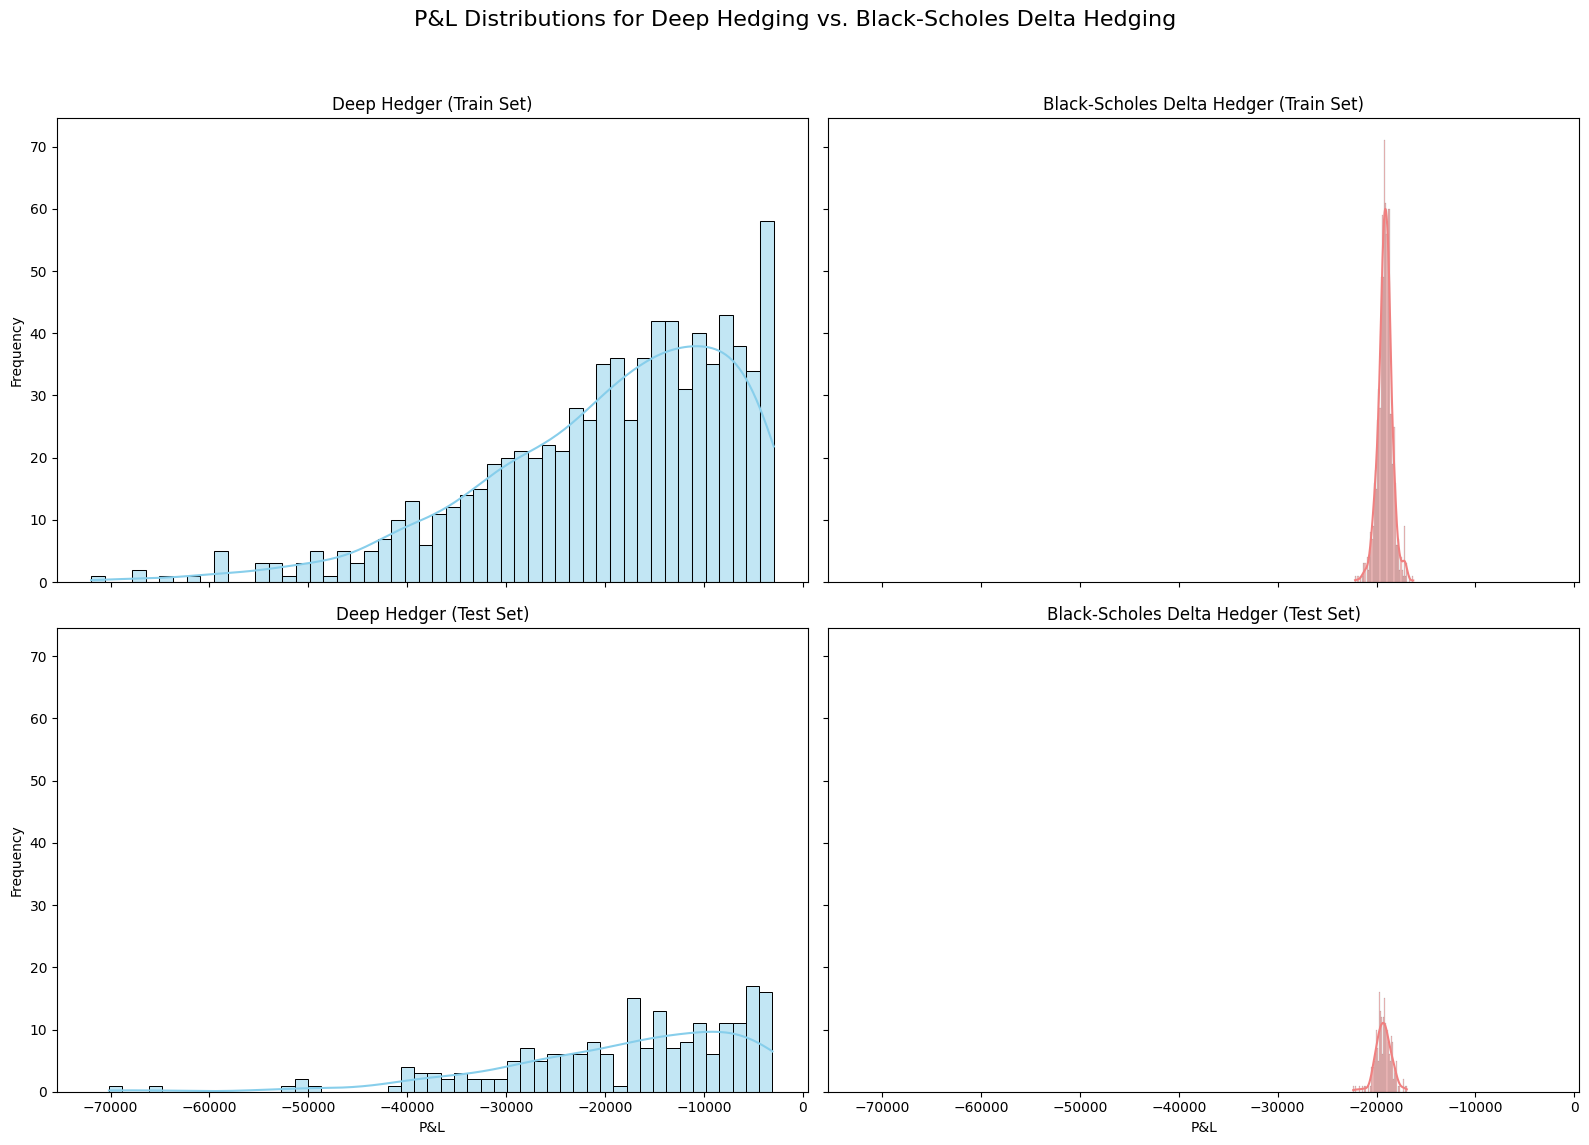


--- Hedging Performance Metrics (alpha = {alph_level:.0%}) ---

Deep Hedger (Train Set):
  Mean P&L: -19445.82
  Std Dev P&L: 12592.10
  VaR (5%): -42362.92
  CVaR (5%): 51730.87

Black-Scholes Delta Hedger (Train Set):
  Mean P&L: -19134.07
  Std Dev P&L: 731.28
  VaR (5%): -20321.82
  CVaR (5%): 20784.79

Deep Hedger (Test Set):
  Mean P&L: -17778.64
  Std Dev P&L: 12148.91
  VaR (5%): -39388.30
  CVaR (5%): 49006.44

Black-Scholes Delta Hedger (Test Set):
  Mean P&L: -19311.28
  Std Dev P&L: 818.66
  VaR (5%): -20465.49
  CVaR (5%): 21168.03


In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

alph_level = 0.05

# --- Plotting P&L Distributions ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex=True, sharey=True)
fig.suptitle('P&L Distributions for Deep Hedging vs. Black-Scholes Delta Hedging', fontsize=16)

sns.histplot(dh_pnl_train, bins=50, kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Deep Hedger (Train Set)')
axes[0, 0].set_xlabel('P&L')
axes[0, 0].set_ylabel('Frequency')

sns.histplot(bs_pnl_train, bins=50, kde=True, ax=axes[0, 1], color='lightcoral')
axes[0, 1].set_title('Black-Scholes Delta Hedger (Train Set)')
axes[0, 1].set_xlabel('P&L')
axes[0, 1].set_ylabel('Frequency')

sns.histplot(dh_pnl_test, bins=50, kde=True, ax=axes[1, 0], color='skyblue')
axes[1, 0].set_title('Deep Hedger (Test Set)')
axes[1, 0].set_xlabel('P&L')
axes[1, 0].set_ylabel('Frequency')

sns.histplot(bs_pnl_test, bins=50, kde=True, ax=axes[1, 1], color='lightcoral')
axes[1, 1].set_title('Black-Scholes Delta Hedger (Test Set)')
axes[1, 1].set_xlabel('P&L')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# --- Reporting VaR and CVaR ---
print("\n--- Hedging Performance Metrics (alpha = {alph_level:.0%}) ---")

# Deep Hedger Train
mean_pnl_dh_train = np.mean(dh_pnl_train)
std_pnl_dh_train = np.std(dh_pnl_train)
var_dh_train = calculate_var(dh_pnl_train, alpha=alph_level)
cvar_dh_train = calculate_cvar_numpy(dh_pnl_train, alpha=alph_level)
print(f"\nDeep Hedger (Train Set):\n  Mean P&L: {mean_pnl_dh_train:.2f}\n  Std Dev P&L: {std_pnl_dh_train:.2f}\n  VaR ({alph_level:.0%}): {var_dh_train:.2f}\n  CVaR ({alph_level:.0%}): {cvar_dh_train:.2f}")

# Black-Scholes Hedger Train
mean_pnl_bs_train = np.mean(bs_pnl_train)
std_pnl_bs_train = np.std(bs_pnl_train)
var_bs_train = calculate_var(bs_pnl_train, alpha=alph_level)
cvar_bs_train = calculate_cvar_numpy(bs_pnl_train, alpha=alph_level)
print(f"\nBlack-Scholes Delta Hedger (Train Set):\n  Mean P&L: {mean_pnl_bs_train:.2f}\n  Std Dev P&L: {std_pnl_bs_train:.2f}\n  VaR ({alph_level:.0%}): {var_bs_train:.2f}\n  CVaR ({alph_level:.0%}): {cvar_bs_train:.2f}")

# Deep Hedger Test
mean_pnl_dh_test = np.mean(dh_pnl_test)
std_pnl_dh_test = np.std(dh_pnl_test)
var_dh_test = calculate_var(dh_pnl_test, alpha=alph_level)
cvar_dh_test = calculate_cvar_numpy(dh_pnl_test, alpha=alph_level)
print(f"\nDeep Hedger (Test Set):\n  Mean P&L: {mean_pnl_dh_test:.2f}\n  Std Dev P&L: {std_pnl_dh_test:.2f}\n  VaR ({alph_level:.0%}): {var_dh_test:.2f}\n  CVaR ({alph_level:.0%}): {cvar_dh_test:.2f}")

# Black-Scholes Hedger Test
mean_pnl_bs_test = np.mean(bs_pnl_test)
std_pnl_bs_test = np.std(bs_pnl_test)
var_bs_test = calculate_var(bs_pnl_test, alpha=alph_level)
cvar_bs_test = calculate_cvar_numpy(bs_pnl_test, alpha=alph_level)
print(f"\nBlack-Scholes Delta Hedger (Test Set):\n  Mean P&L: {mean_pnl_bs_test:.2f}\n  Std Dev P&L: {std_pnl_bs_test:.2f}\n  VaR ({alph_level:.0%}): {var_bs_test:.2f}\n  CVaR ({alph_level:.0%}): {cvar_bs_test:.2f}")